# EDA

In [2]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm

TRAIN_IMG_DIR = "/kaggle/input/data-science-ara-7-0/dataset/dataset/train/images"
TRAIN_MASK_DIR = "/kaggle/input/data-science-ara-7-0/dataset/dataset/train/mask"

train_images = sorted(glob(os.path.join(TRAIN_IMG_DIR, "*")))
train_masks = sorted(glob(os.path.join(TRAIN_MASK_DIR, "*")))

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print("Total Train Images :", len(train_images))
print("Total Train Masks  :", len(train_masks))
print()

areas = []
total_fg = 0
total_pixels = 0

for mask_path in tqdm(train_masks):
    mask = cv2.imread(mask_path, 0)
    fg = (mask > 0).sum()
    total = mask.size
    
    areas.append(fg / total)
    total_fg += fg
    total_pixels += total

areas = np.array(areas)

print("="*50)
print("POTHOLE AREA STATISTICS")
print("="*50)
print(f"Min Area %   : {areas.min()*100:.4f}%")
print(f"Max Area %   : {areas.max()*100:.4f}%")
print(f"Mean Area %  : {areas.mean()*100:.4f}%")
print(f"Median Area %: {np.median(areas)*100:.4f}%")
print()

print("="*50)
print("COVERAGE STATISTICS")
print("="*50)
print(f"Total Foreground % : {(total_fg/total_pixels)*100:.4f}%")
print(f"Total Background % : {(1-total_fg/total_pixels)*100:.4f}%")
print(f"Images with Empty Mask : {(areas==0).sum()}")
print("="*50)


DATASET OVERVIEW
Total Train Images : 498
Total Train Masks  : 498



100%|██████████| 498/498 [00:10<00:00, 48.53it/s]

POTHOLE AREA STATISTICS
Min Area %   : 0.0235%
Max Area %   : 67.4005%
Mean Area %  : 13.4860%
Median Area %: 9.1678%

COVERAGE STATISTICS
Total Foreground % : 8.3920%
Total Background % : 91.6080%
Images with Empty Mask : 0


## Insight dari Statistik Dataset

### 1. Konsistensi Dataset
- Total train images dan train masks sama (498).
- Tidak ada mask kosong (Images with Empty Mask: 0).

Implikasi:
- Semua gambar mengandung pothole.
- Model tidak belajar dari contoh jalan tanpa lubang (clean road), sehingga berpotensi meningkatkan false positive saat inference di data nyata.

---

### 2. Distribusi Luas Pothole (% Area)

- Minimum: 0.0235%
- Maksimum: 67.4005%
- Mean: 13.4860%
- Median: 9.1678%

Insight:
- Mean lebih besar dari median → distribusi right-skewed.
- Sebagian besar pothole relatif kecil (<10% area gambar).
- Variasi ukuran sangat besar, dari sangat kecil hingga sangat luas.

Implikasi:
- Model harus sensitif terhadap objek kecil.
- Perlu pendekatan multi-scale atau loss function yang mendukung deteksi small object.

---

### 3. Ketidakseimbangan Piksel (Foreground vs Background)

- Total Foreground: 8.3920%
- Total Background: 91.6080%

Insight:
- Dataset sangat imbalanced secara piksel.
- Mayoritas piksel adalah background.

Implikasi:
- Accuracy saja tidak cukup sebagai metrik evaluasi.
- Disarankan menggunakan Dice, IoU, Precision, dan Recall.
- Gunakan loss function yang menangani class imbalance (misalnya Dice Loss, Tversky Loss, atau kombinasi BCE + Dice).

---

## Kesimpulan

Dataset memiliki:
- Variasi ukuran objek yang ekstrem,
- Dominasi background yang tinggi,
- Tidak ada contoh negatif murni.

Pipeline training sebaiknya mencakup strategi resizing yang konsisten, arsitektur multi-scale, serta loss dan metrik yang sesuai untuk menangani ketidakseimbangan kelas dan variasi ukuran objek.


## Rendered Train Images

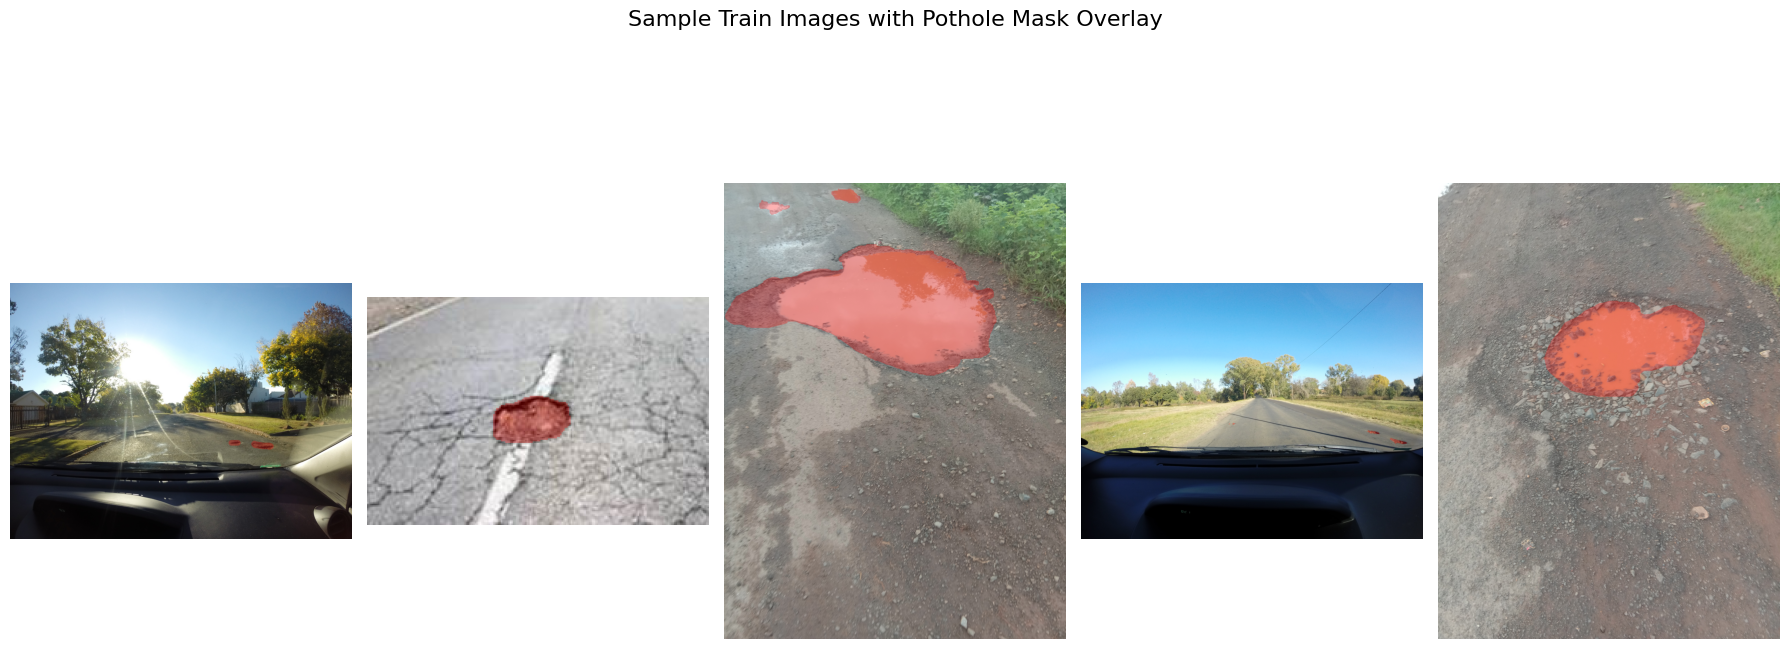

In [3]:
import matplotlib.pyplot as plt
import random

def overlay_mask(img, mask):
    overlay = img.copy()
    overlay[mask > 0] = [255, 0, 0]  # Red overlay
    return cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

indices = random.sample(range(len(train_images)), 5)

plt.figure(figsize=(18,8))

for i, idx in enumerate(indices):
    img = cv2.imread(train_images[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(train_masks[idx], 0)
    
    combined = overlay_mask(img, mask)
    
    plt.subplot(1,5,i+1)
    plt.imshow(combined)
    plt.axis("off")

plt.suptitle("Sample Train Images with Pothole Mask Overlay", fontsize=16)
plt.tight_layout()
plt.show()


## Image Size Distribution

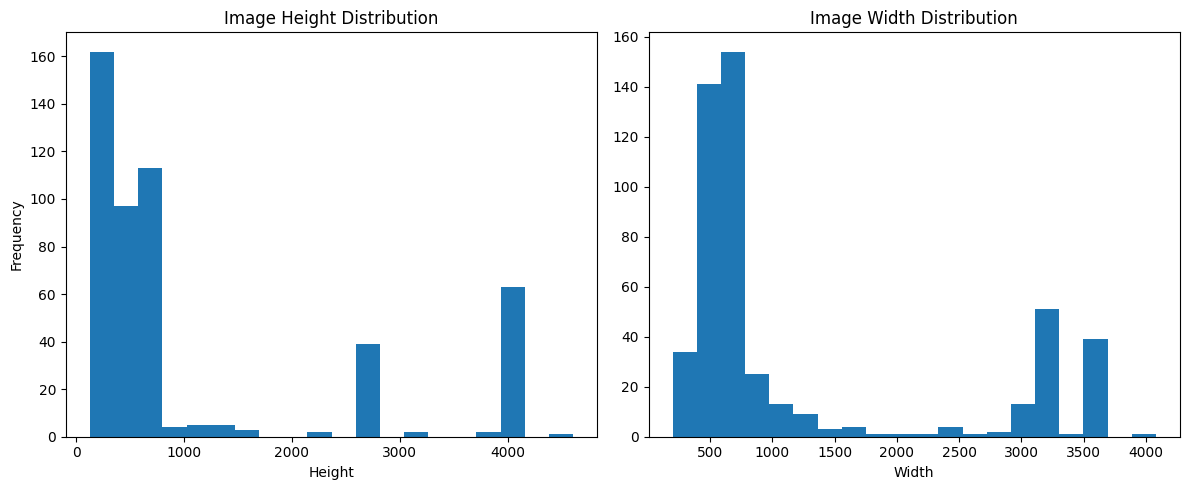

In [4]:
heights = []
widths = []

for img_path in train_images:
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    heights.append(h)
    widths.append(w)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")

plt.tight_layout()
plt.show()



## Pothole Coverage Distribution

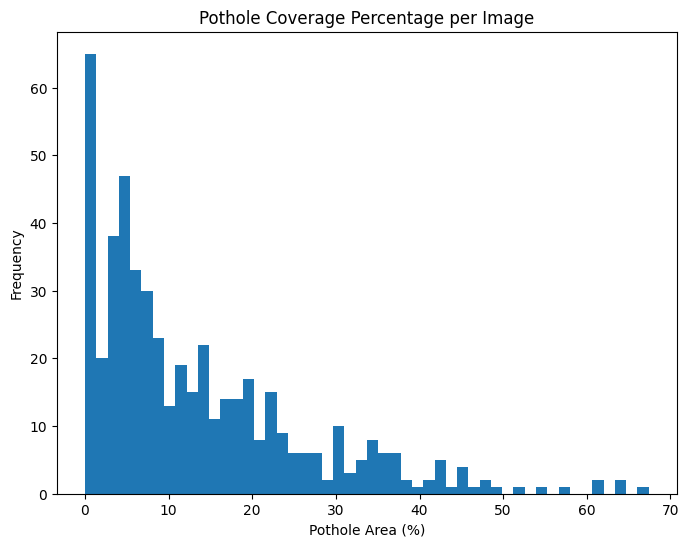

SIZE CATEGORY SUMMARY
Small  (<1%)  : 59
Medium (1-5%) : 95
Large  (>5%)  : 344


In [5]:
plt.figure(figsize=(8,6))
plt.hist(areas * 100, bins=50)
plt.title("Pothole Coverage Percentage per Image")
plt.xlabel("Pothole Area (%)")
plt.ylabel("Frequency")
plt.show()

# Optional: categorize sizes
small = np.sum(areas < 0.01)
medium = np.sum((areas >= 0.01) & (areas < 0.05))
large = np.sum(areas >= 0.05)

print("="*50)
print("SIZE CATEGORY SUMMARY")
print("="*50)
print(f"Small  (<1%)  : {small}")
print(f"Medium (1-5%) : {medium}")
print(f"Large  (>5%)  : {large}")
print("="*50)


## Brightness Analysis

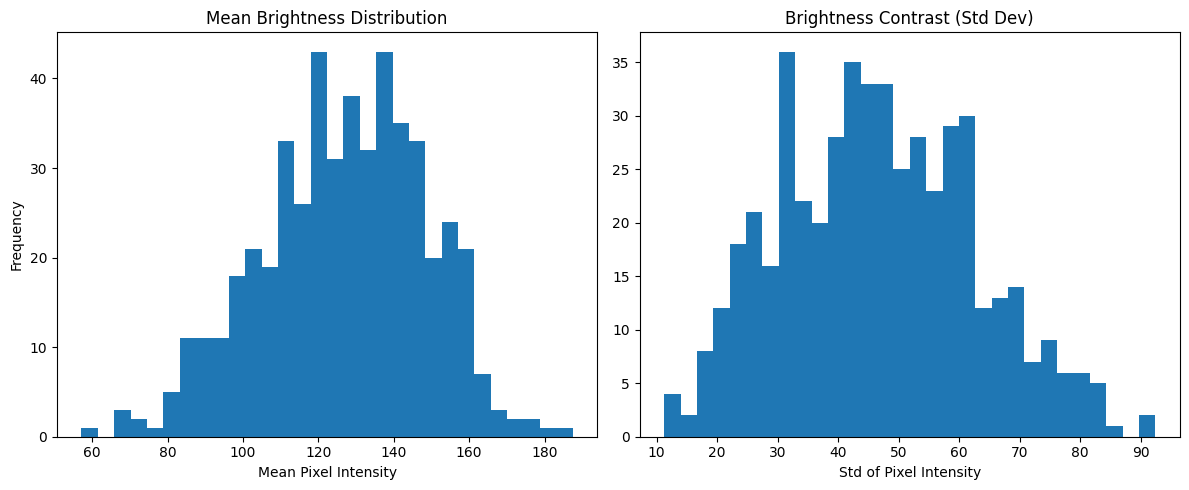

BRIGHTNESS STATS
Min Mean Brightness : 57.13
Max Mean Brightness : 187.47
Avg Mean Brightness : 126.84

Min Contrast : 11.25
Max Contrast : 92.43
Avg Contrast : 46.56


In [6]:
brightness_means = []
brightness_stds = []

for img_path in train_images:
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    brightness_means.append(gray.mean())
    brightness_stds.append(gray.std())

brightness_means = np.array(brightness_means)
brightness_stds = np.array(brightness_stds)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(brightness_means, bins=30)
plt.title("Mean Brightness Distribution")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(brightness_stds, bins=30)
plt.title("Brightness Contrast (Std Dev)")
plt.xlabel("Std of Pixel Intensity")

plt.tight_layout()
plt.show()

print("="*50)
print("BRIGHTNESS STATS")
print("="*50)
print(f"Min Mean Brightness : {brightness_means.min():.2f}")
print(f"Max Mean Brightness : {brightness_means.max():.2f}")
print(f"Avg Mean Brightness : {brightness_means.mean():.2f}")
print()
print(f"Min Contrast : {brightness_stds.min():.2f}")
print(f"Max Contrast : {brightness_stds.max():.2f}")
print(f"Avg Contrast : {brightness_stds.mean():.2f}")
print("="*50)


## Insight 

### 1. Brightness (Rata-rata Intensitas)

- Minimum Mean Brightness: 57.13  
- Maksimum Mean Brightness: 187.47  
- Rata-rata Mean Brightness: 126.84  

Insight:
- Rentang brightness cukup lebar, dari kondisi relatif gelap hingga sangat terang.
- Variasi pencahayaan antar gambar cukup signifikan.

Implikasi:
- Model harus robust terhadap perubahan pencahayaan.
- Disarankan menggunakan augmentasi seperti random brightness/gamma.
- Normalisasi input (mean-std normalization) menjadi penting untuk stabilitas training.

---

### 2. Contrast

- Minimum Contrast: 11.25  
- Maksimum Contrast: 92.43  
- Rata-rata Contrast: 46.56  

Insight:
- Terdapat variasi kontras yang cukup besar antar gambar.
- Beberapa gambar memiliki kontras rendah (detail pothole bisa kurang jelas).
- Beberapa lainnya memiliki kontras tinggi (tepi lebih tajam).

Implikasi:
- Model perlu mampu menangani detail yang kurang jelas pada gambar low-contrast.
- Augmentasi seperti random contrast atau CLAHE dapat membantu meningkatkan generalisasi.

---

## Kesimpulan

Dataset memiliki variasi pencahayaan dan kontras yang cukup besar. Pipeline preprocessing dan augmentasi perlu dirancang agar model tetap stabil dan generalizable terhadap kondisi jalan dengan pencahayaan yang berbeda-beda.


## Blur / Sharpness Analysis

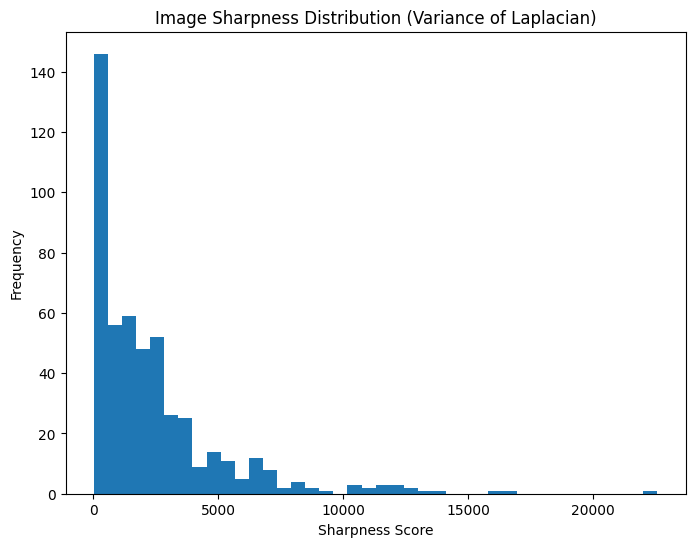

SHARPNESS STAT
Min Sharpness : 17.44
Max Sharpness : 22579.67
Mean Sharpness: 2415.08


In [7]:
def laplacian_variance(image):
    return cv2.Laplacian(image, cv2.CV_64F).var()

sharpness_scores = []

for img_path in train_images:
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sharpness_scores.append(laplacian_variance(gray))

sharpness_scores = np.array(sharpness_scores)

plt.figure(figsize=(8,6))
plt.hist(sharpness_scores, bins=40)
plt.title("Image Sharpness Distribution (Variance of Laplacian)")
plt.xlabel("Sharpness Score")
plt.ylabel("Frequency")
plt.show()

print("SHARPNESS STAT")
print(f"Min Sharpness : {sharpness_scores.min():.2f}")
print(f"Max Sharpness : {sharpness_scores.max():.2f}")
print(f"Mean Sharpness: {sharpness_scores.mean():.2f}")


## Insight

### 1. Distribusi Sharpness

- Minimum Sharpness: 17.44  
- Maksimum Sharpness: 22579.67  
- Rata-rata Sharpness: 2415.08  

Insight:
- Rentang sharpness sangat lebar, menunjukkan variasi kualitas fokus antar gambar.
- Distribusi terlihat right-skewed, dengan sebagian besar gambar memiliki sharpness rendah–menengah, dan beberapa outlier sangat tajam.
- Nilai minimum yang sangat rendah mengindikasikan adanya gambar yang cukup blur.

---

### 2. Implikasi terhadap Model

- Gambar dengan sharpness rendah (blur) dapat menyulitkan deteksi tepi pothole.
- Model perlu robust terhadap variasi kualitas fokus.
- Outlier dengan sharpness sangat tinggi bisa menyebabkan distribusi fitur tidak stabil jika tidak dinormalisasi dengan baik.

---

### 3. Aksi Selanjutnya
  - Data augmentation seperti random blur agar model tidak sensitif terhadap fokus.
  - Filtering atau analisis manual jika terdapat gambar yang terlalu blur dan berpotensi merusak training.
  - Normalisasi dan augmentasi konsisten untuk menjaga stabilitas distribusi fitur.

---

## Kesimpulan

Dataset memiliki variasi ketajaman yang signifikan, dari gambar cukup blur hingga sangat tajam. Pipeline training sebaiknya mempertimbangkan robustness terhadap variasi fokus agar performa model tetap stabil pada kondisi dunia nyata.


## Spatial Distribution Analysis

100%|██████████| 498/498 [00:08<00:00, 56.62it/s]


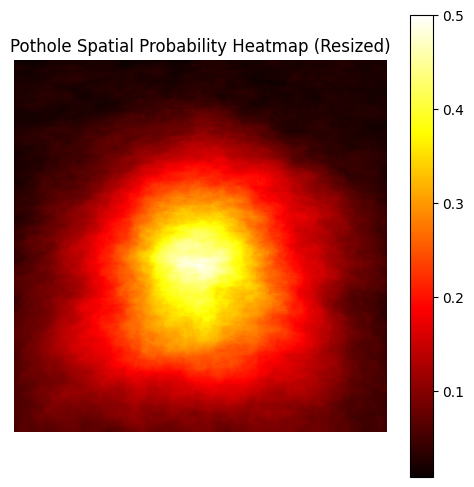

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

TARGET_SIZE = 512  

heatmap_accum = np.zeros((TARGET_SIZE, TARGET_SIZE), dtype=np.float32)

for mask_path in tqdm(train_masks):
    mask = cv2.imread(mask_path, 0)
    binary = (mask > 0).astype(np.float32)
    
    # Resize ke ukuran seragam
    binary_resized = cv2.resize(binary, 
                                (TARGET_SIZE, TARGET_SIZE), 
                                interpolation=cv2.INTER_NEAREST)
    
    heatmap_accum += binary_resized

heatmap_accum /= len(train_masks)

plt.figure(figsize=(6,6))
plt.imshow(heatmap_accum, cmap="hot")
plt.title("Pothole Spatial Probability Heatmap (Resized)")
plt.colorbar()
plt.axis("off")
plt.show()


## Insight

### 1. Pola Distribusi Spasial

Heatmap menunjukkan bahwa probabilitas kemunculan pothole paling tinggi berada di area tengah gambar, dan menurun secara bertahap ke arah tepi.

Insight:
- Pothole cenderung muncul di bagian tengah frame.
- Area tepi (atas, bawah, kiri, kanan) memiliki probabilitas lebih rendah.
- Distribusi bersifat terpusat (center-biased).

---

### 2. Kemungkinan Penyebab

- Sudut pengambilan gambar kemungkinan konsisten (kamera kendaraan mengarah ke depan).
- Jalan berada di bagian tengah frame, sementara bagian atas sering berisi langit atau latar belakang non-jalan.
- Bagian bawah atau sisi gambar mungkin berisi area yang jarang mengandung pothole.

---

### 3. Implikasi untuk Model

- Model mungkin belajar bias posisi (positional bias).
- Risikonya, jika pada data baru pothole muncul di tepi gambar, model bisa kurang akurat.
- Model bisa terlalu mengandalkan lokasi spasial, bukan fitur tekstur.

---

### 4. Rekomendasi

- Gunakan augmentasi seperti:
  - Random crop
  - Random shift / translation
  - Horizontal flip
- Pastikan resizing tidak selalu mempertahankan alignment yang sama.
- Evaluasi performa pada sampel dengan pothole di area tepi.

---

## Kesimpulan

Dataset memiliki bias spasial yang cukup jelas: pothole lebih sering muncul di tengah gambar. Pipeline training sebaiknya mengurangi ketergantungan model terhadap lokasi absolut agar generalisasi tetap baik pada distribusi spasial yang berbeda.


## Object Count Analysis

100%|██████████| 498/498 [00:09<00:00, 53.86it/s]


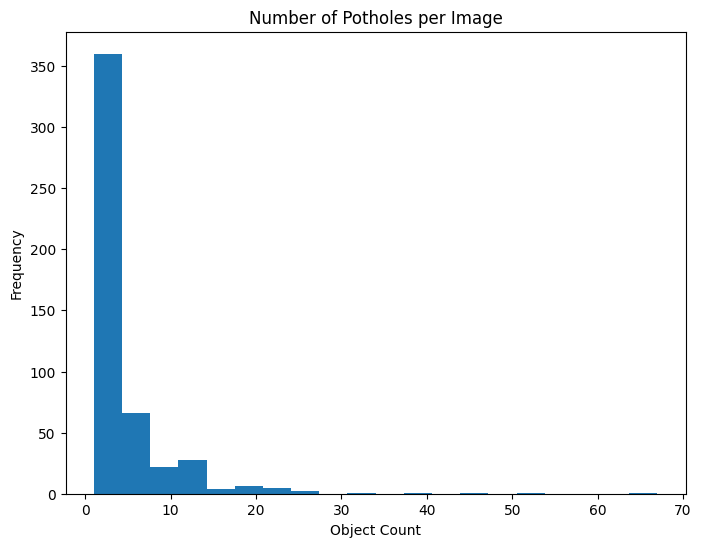

OBJECT COUNT STATS
Min Objects : 1
Max Objects : 67
Mean Objects: 4.26


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

object_counts = []

for mask_path in tqdm(train_masks):
    mask = cv2.imread(mask_path, 0)
    binary = (mask > 0).astype(np.uint8)
    
    num_labels, _ = cv2.connectedComponents(binary)
    object_counts.append(num_labels - 1)  # minus background

object_counts = np.array(object_counts)

plt.figure(figsize=(8,6))
plt.hist(object_counts, bins=20)
plt.title("Number of Potholes per Image")
plt.xlabel("Object Count")
plt.ylabel("Frequency")
plt.show()

print("="*50)
print("OBJECT COUNT STATS")
print("="*50)
print(f"Min Objects : {object_counts.min()}")
print(f"Max Objects : {object_counts.max()}")
print(f"Mean Objects: {object_counts.mean():.2f}")
print("="*50)


## Insight

### 1. Distribusi Jumlah Objek

- Minimum Objects: 1  
- Maksimum Objects: 67  
- Rata-rata Objects: 4.26  

Insight:
- Sebagian besar gambar memiliki jumlah pothole yang sedikit.
- Distribusi bersifat right-skewed: banyak gambar dengan 1–5 pothole, dan sedikit gambar dengan jumlah sangat banyak (outlier hingga 67).
- Variasi jumlah objek cukup besar antar gambar.

---

### 2. Implikasi terhadap Model

- Model harus mampu menangani:
  - Kasus sederhana (1 objek besar).
  - Kasus kompleks (banyak objek kecil tersebar).
- Gambar dengan banyak pothole kemungkinan berisi objek kecil yang saling berdekatan, yang dapat:
  - Menyulitkan segmentasi batas antar objek.
  - Meningkatkan risiko over-segmentation atau under-segmentation.

---

### 3. Risiko Potensial

- Jika mayoritas gambar hanya memiliki sedikit objek, model bisa bias terhadap skenario sederhana.
- Gambar dengan banyak pothole dapat berfungsi sebagai hard samples dan mempengaruhi stabilitas training.

---

## Kesimpulan

Dataset menunjukkan variasi jumlah objek yang cukup besar, dengan mayoritas gambar memiliki sedikit pothole dan sebagian kecil memiliki jumlah sangat banyak. Model perlu robust terhadap variasi kepadatan objek, terutama dalam kasus banyak pothole kecil dalam satu gambar.


## Train vs Test Shift Detection

100%|██████████| 295/295 [00:08<00:00, 34.25it/s]


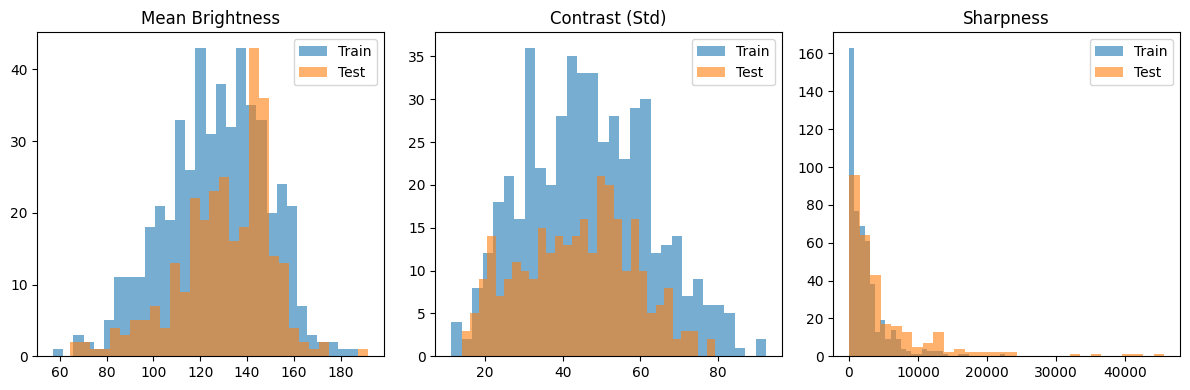

In [10]:
TEST_IMG_DIR = "/kaggle/input/data-science-ara-7-0/dataset/dataset/test/images"
test_images = sorted(glob(os.path.join(TEST_IMG_DIR, "*")))

def compute_stats(image_paths):
    means = []
    stds = []
    sharpness = []
    
    for img_path in tqdm(image_paths):
        img = cv2.imread(img_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        means.append(gray.mean())
        stds.append(gray.std())
        sharpness.append(cv2.Laplacian(gray, cv2.CV_64F).var())
        
    return np.array(means), np.array(stds), np.array(sharpness)

train_mean, train_std, train_sharp = compute_stats(train_images)
test_mean, test_std, test_sharp = compute_stats(test_images)

# Plot Brightness
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(train_mean, bins=30, alpha=0.6, label="Train")
plt.hist(test_mean, bins=30, alpha=0.6, label="Test")
plt.title("Mean Brightness")
plt.legend()

plt.subplot(1,3,2)
plt.hist(train_std, bins=30, alpha=0.6, label="Train")
plt.hist(test_std, bins=30, alpha=0.6, label="Test")
plt.title("Contrast (Std)")
plt.legend()

plt.subplot(1,3,3)
plt.hist(train_sharp, bins=30, alpha=0.6, label="Train")
plt.hist(test_sharp, bins=30, alpha=0.6, label="Test")
plt.title("Sharpness")
plt.legend()

plt.tight_layout()
plt.show()


## Insight

Berdasarkan distribusi Mean Brightness, Contrast, dan Sharpness antara data train dan test:

### 1. Mean Brightness
- Distribusi train dan test relatif mirip.
- Test cenderung sedikit lebih terang pada beberapa rentang nilai.
- Tidak terlihat pergeseran ekstrem.

Kesimpulan:  
Tidak ada brightness shift yang signifikan. Model kemungkinan cukup stabil terhadap pencahayaan global.

---

### 2. Contrast (Std)
- Distribusi train dan test cukup overlap.
- Test tampak sedikit lebih terkonsentrasi pada rentang tertentu.
- Perbedaan tidak terlalu drastis.

Kesimpulan:  
Perbedaan kontras relatif kecil dan kemungkinan tidak menyebabkan domain shift besar.

---

### 3. Sharpness
- Distribusi sama-sama right-skewed.
- Test memiliki lebih banyak nilai ekstrem (sharpness sangat tinggi).
- Variasi sharpness di test terlihat lebih lebar.

Kesimpulan:  
Sharpness adalah faktor dengan potensi domain shift paling besar dibanding brightness dan contrast.

---

## Ringkasan Umum

- Tidak terlihat domain shift besar pada brightness dan contrast.
- Sharpness menunjukkan variasi lebih tinggi pada test set.
- Model perlu robust terhadap variasi ketajaman (blur ↔ sangat tajam).

Aksi selanjutnya:
- Gunakan augmentasi blur.
- Pastikan normalisasi konsisten antara train dan test.
- Evaluasi performa khusus pada sampel dengan sharpness ekstrem.


## Summary

## Informasi Dasar Data
- **Ukuran Dataset:** Dataset terdiri dari 498 gambar training beserta file mask yang bersesuaian.

- **Konvensi Penamaan File:**  
  Gambar dinamai `train_XXX.jpg`, sedangkan mask dinamai `mask_XXX.png`.  

- **Dimensi Gambar:**  
  Gambar pada dataset training memiliki variasi dimensi yang cukup signifikan:
  - Tinggi gambar berkisar antara 129 hingga 4608 piksel.
  - Lebar gambar berkisar antara 200 hingga 4080 piksel.
  - Tidak terdapat satu resolusi yang seragam untuk seluruh gambar.

- **Luas Lubang (dalam piksel):**
  - Luas minimum lubang yang terdeteksi: 123 piksel.
  - Luas maksimum lubang yang terdeteksi: 6.700.923 piksel.
  - Rata-rata luas lubang: 238.130,32 piksel.
  - Median luas lubang: 29.467 piksel.
  - Distribusi luas lubang sangat miring (*skewed*), dengan standar deviasi sebesar **652.957,11**, yang menunjukkan rentang ukuran lubang yang sangat beragam, mulai dari sangat kecil hingga sangat besar.

- **Cakupan Lubang (sebagai persentase dari luas gambar):**
  - Cakupan minimum: 0,02%.
  - Cakupan maksimum: 67,40%.
  - Rata-rata cakupan: 13,49%.
  - Median cakupan: 9,17%.
  - Standar deviasi cakupan sebesar **12,86%**, menunjukkan variasi yang cukup besar dalam proporsi area gambar yang tertutup lubang. Banyak gambar hanya memiliki lubang kecil, sementara sebagian kecil lainnya menunjukkan kerusakan yang sangat luas.

---

## Insight Lebih Lanjut

- **Pra-pemrosesan untuk Training Model:**  
  Mengingat variasi dimensi gambar yang cukup besar, diperlukan strategi *resizing* yang konsisten sebelum gambar dimasukkan ke dalam neural network. Strategi ini dapat berupa:
  - Padding
  - Cropping
  - Scaling ke ukuran input yang tetap

- **Mengatasi Ketidakseimbangan Data:**  
  Rentang luas dan persentase cakupan lubang yang sangat beragam dapat menjadi tantangan dalam proses training, terutama untuk lubang yang sangat kecil atau sangat besar. Beberapa pendekatan yang dapat dipertimbangkan:
  - Penggunaan *weighted loss function*
  - *Data augmentation* yang mempertimbangkan variasi skala
  - Arsitektur dengan fitur *multi-scale*


# Final Pipeline

In [11]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.8 MB/s eta 0:00:00


## Best 1

In [12]:
#Inisiasi Library
import os

def install_packages():
    try:
        import segmentation_models_pytorch
        print("No error")
    except ImportError:
        os.system("pip install -q segmentation-models-pytorch timm")
        print("Instalasi done")

install_packages()

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

No error


In [13]:
#Setup
import cv2
import gc
import zipfile
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from skimage import measure

### Resize semua gambar ke 640×640 untuk konsistensi input

In [ ]:
#Config
class Config:
    ROOT_DIR = "/kaggle/input/data-science-ara-7-0/dataset/dataset" 
    TRAIN_DIR = f"{ROOT_DIR}/train"
    TEST_DIR  = f"{ROOT_DIR}/test"
    
    IMG_SIZE = 640       
    BATCH_SIZE = 4       
    EPOCHS = 25          
    LR = 6e-5            
    

    ENCODER = "mit_b3" 
    WEIGHTS = "imagenet"
    
    # Filter Area dinamis (dikecilkan agar pothole kecil tidak terbuang)
    MIN_AREA_RATIO = 0.00003 
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()

### Utilitas RLE dan Loader Dataset

In [15]:
#RLE
def encode_rle(mask):
    pixels = (mask == 255).astype(np.uint8).T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(map(str, runs))

class PotholeDataset(Dataset):
    def __init__(self, imgs, masks=None, tfms=None):
        self.imgs, self.masks, self.tfms = imgs, masks, tfms

    def __len__(self): return len(self.imgs)

    def __getitem__(self, i):
        img = cv2.imread(self.imgs[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.masks is not None:
            mask = cv2.imread(self.masks[i], 0)
            mask = np.where(mask > 127, 255, 0).astype(np.uint8)
            mask = mask / 255.0
            
            if self.tfms:
                aug = self.tfms(image=img, mask=mask)
                return aug["image"], aug["mask"].unsqueeze(0)
        
        if self.tfms:
            aug = self.tfms(image=img)
            return aug["image"]
        return img

### Augmentasi menggunakan albumentasi untuk cegah overfitting

Perhatikan bahwa setiap pothole sering memiliki komposisi yang berbeda-beda, lebih banyak pothole yang berada pada jalan mulus dibandingkan jalan berlubang. Diharapkan dengan penggunaan augmentasi albumentasi ini, satu gambar pothole bisa digeneralisasi menjadi berbagai variasi parameter yang sudah diolah sehingga model dapat belajar lebih robust.

In [16]:
train_tfms = A.Compose([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    
    A.Perspective(scale=(0.05, 0.1), p=0.4), 
    
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
    
    A.OneOf([
        A.CLAHE(clip_limit=2.0),
        A.RandomGamma(gamma_limit=(80, 120)),
        A.ColorJitter(brightness=0.2, contrast=0.2),
    ], p=0.5),
    
    A.RandomShadow(num_shadows_lower=1, num_shadows_upper=2, shadow_dimension=5, p=0.3),
    
    A.Normalize(),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

/tmp/ipykernel_25/3185941901.py:17: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
  A.RandomShadow(num_shadows_lower=1, num_shadows_upper=2, shadow_dimension=5, p=0.3),


### Pemisahan Data

In [17]:
imgs = sorted(glob(f"{cfg.TRAIN_DIR}/images/*.jpg"))
masks = [f"{cfg.TRAIN_DIR}/mask/mask_{os.path.basename(x)[6:-4]}.png" for x in imgs]


tr_i, va_i, tr_m, va_m = train_test_split(imgs, masks, test_size=0.1, random_state=2024)

train_dl = DataLoader(PotholeDataset(tr_i, tr_m, train_tfms), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_dl   = DataLoader(PotholeDataset(va_i, va_m, val_tfms), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

ValueError: With n_samples=0, test_size=0.1 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

### Modelling

Model manet dipilih karena model ini memiliki Attention Mechanism yang akan membantu dalam membedakan antara fitur jalan yang relevan dan noise-noise yang ada, sekaligus menjaga konteks global tekstur aspal.

In [ ]:
#Model
print(f"Building Model: MANet ({cfg.ENCODER})...")

model = smp.MAnet(
    encoder_name=cfg.ENCODER,
    encoder_weights=cfg.WEIGHTS,
    in_channels=3,
    classes=1,
    decoder_pab_channels=64,
    decoder_use_batchnorm=True,
).to(cfg.DEVICE)

# Loss
dice_loss = smp.losses.DiceLoss(mode="binary")
tversky_loss = smp.losses.TverskyLoss(mode="binary", alpha=0.3, beta=0.7)
focal_loss = smp.losses.FocalLoss(mode="binary", alpha=0.25, gamma=2.0)

def criterion(pred, target):
    return 0.35 * dice_loss(pred, target) + 0.5 * tversky_loss(pred, target) + 0.15 * focal_loss(pred, target)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-3)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)
scaler = GradScaler()

#### Trainning Model Manet

In [ ]:
best_score = 0
print("Starting Training")

for e in range(cfg.EPOCHS):
    model.train()
    train_loss = 0
    
    for x, y in tqdm(train_dl, leave=False, desc=f"Epoch {e+1}"):
        x, y = x.to(cfg.DEVICE), y.to(cfg.DEVICE)
        
        optimizer.zero_grad()
        with autocast():
            preds = model(x)
            loss = criterion(preds, y)
        
        scaler.scale(loss).backward()
        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
    
    scheduler.step()
    
    
    model.eval()
    val_dice = []
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(cfg.DEVICE), y.to(cfg.DEVICE)
            
            # Inference
            preds = torch.sigmoid(model(x))
            pred_mask = (preds > 0.5).float()
            
            # Dice Calculation
            i = (pred_mask * y).sum()
            u = pred_mask.sum() + y.sum()
            score = (2. * i) / (u + 1e-7)
            val_dice.append(score.item())
    
    avg_dice = np.mean(val_dice)
    print(f"Epoch {e+1} | Loss: {train_loss/len(train_dl):.4f} | Val Dice: {avg_dice:.4f}")
    
    if avg_dice > best_score:
        best_score = avg_dice
        torch.save(model.state_dict(), "best_manet_model.pth")
        print(f"Saved Best Model: {best_score:.4f}")

### Proses Prediksi Test Case

Pada proses prediksi pothole pada test case, model menggunakan 4 skala zoom berbeda dan posisi yang dibalik , setelah itu menghitung rata-ratanya agar prediksi lebih akurat.

In [ ]:
print("\nBagian Inference with Multi-Scale TTA...")

if os.path.exists("best_manet_model.pth"):
    model.load_state_dict(torch.load("best_manet_model.pth"))
else:
    print("Warning: Model weights not found. Using random weights.")

model.eval()

test_imgs = sorted(glob(f"{cfg.TEST_DIR}/images/*.jpg"))
submission = []

def get_min_area(h, w):
    return int(h * w * cfg.MIN_AREA_RATIO)

if len(test_imgs) == 0:
    print("Tidak ada gambar test ditemukan. Cek path dataset.")
else:
    for path in tqdm(test_imgs):
        original_img = cv2.imread(path)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        h_orig, w_orig = original_img.shape[:2]
        
        tta_preds = []
        

        scales = [0.75, 1.0, 1.25, 1.5]
        
        for scale in scales:
            if scale != 1.0:
                img_scaled = cv2.resize(original_img, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)
            else:
                img_scaled = original_img.copy()
                
            for flip in [False, True]:
                img_in = cv2.flip(img_scaled, 1) if flip else img_scaled
                
                t_input = val_tfms(image=img_in)["image"].unsqueeze(0).to(cfg.DEVICE)
                
                with torch.no_grad():
                    pred = torch.sigmoid(model(t_input))[0, 0].cpu().numpy()
                
                if flip: pred = cv2.flip(pred, 1)
                
                pred = cv2.resize(pred, (w_orig, h_orig), interpolation=cv2.INTER_LINEAR)
                tta_preds.append(pred)
                
        final_pred = np.mean(tta_preds, axis=0)
        
        mean_val = np.mean(original_img) / 255.0
        thresh = 0.50 if mean_val < 0.3 else 0.40
        
        binary_mask = (final_pred > thresh).astype(np.uint8) * 255
        
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
        
        min_area_thresh = get_min_area(h_orig, w_orig)
        labels = measure.label(binary_mask, connectivity=2)
        clean_mask = np.zeros_like(binary_mask)
        for region in measure.regionprops(labels):
            if region.area > min_area_thresh:
                clean_mask[labels == region.label] = 255

        submission.append({"ImageId": os.path.basename(path),"rle": encode_rle(clean_mask)})

    
    render_dir = "rendered_images"
    os.makedirs(render_dir, exist_ok=True)
    print(f"\nSaving rendered images to '{render_dir}/'...")
    
    for path in tqdm(test_imgs, desc="Rendering"):
        original_img = cv2.imread(path)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        h_orig, w_orig = original_img.shape[:2]
        
        t_input = val_tfms(image=original_img)["image"].unsqueeze(0).to(cfg.DEVICE)
        with torch.no_grad():
            pred = torch.sigmoid(model(t_input))[0, 0].cpu().numpy()
        pred = cv2.resize(pred, (w_orig, h_orig), interpolation=cv2.INTER_LINEAR)
        pred_binary = (pred > 0.45).astype(np.uint8) * 255
        
        overlay = original_img.copy()
        mask_colored = np.zeros_like(overlay)
        mask_colored[:, :, 0] = pred_binary  # Red channel
        overlay = cv2.addWeighted(overlay, 0.7, mask_colored, 0.3, 0)
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].imshow(original_img)
        axes[0].set_title("Original")
        axes[0].axis("off")
        axes[1].imshow(pred_binary, cmap="gray")
        axes[1].set_title("Predicted Mask")
        axes[1].axis("off")
        axes[2].imshow(overlay)
        axes[2].set_title("Overlay")
        axes[2].axis("off")
        plt.suptitle(os.path.basename(path), fontsize=14)
        plt.tight_layout()
        
        save_name = os.path.splitext(os.path.basename(path))[0] + "_render.png"
        plt.savefig(os.path.join(render_dir, save_name), dpi=100, bbox_inches='tight')
        plt.close()
    
    print(f"{len(test_imgs)} rendered images saved to '{render_dir}/'")

    pd.DataFrame(submission).to_csv("submission_manet_advanced_v3.csv", index=False)
    print("Submission Ready: submission_manet_advanced_v3.csv")


# score: 0.76442

## Best 2

In [ ]:
#Instalasi Library
import os
def install_packages():
    try:
        import segmentation_models_pytorch
    except ImportError:
        os.system("pip install -q segmentation-models-pytorch timm")
        print("Instalasi Selesai")

install_packages()

In [ ]:
#Setup
import cv2
import gc
import zipfile
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from skimage import measure

In [ ]:
#Config
class Config:
    ROOT_DIR = "/kaggle/input/data-science-ara-7-0/dataset/dataset" 
    TRAIN_DIR = f"{ROOT_DIR}/train"
    TEST_DIR  = f"{ROOT_DIR}/test"
    
    IMG_SIZE = 640       
    BATCH_SIZE = 4       
    EPOCHS = 25          
    LR = 6e-5            
    
    ENCODER = "mit_b3" 
    WEIGHTS = "imagenet"
    
    MIN_AREA_RATIO = 0.00005 
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()

In [ ]:
def encode_rle(mask):
    pixels = (mask == 255).astype(np.uint8).T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(map(str, runs))

class PotholeDataset(Dataset):
    def __init__(self, imgs, masks=None, tfms=None):
        self.imgs, self.masks, self.tfms = imgs, masks, tfms

    def __len__(self): return len(self.imgs)

    def __getitem__(self, i):
        img = cv2.imread(self.imgs[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.masks is not None:
            mask = cv2.imread(self.masks[i], 0)
            mask = np.where(mask > 127, 255, 0).astype(np.uint8)
            mask = mask / 255.0
            
            if self.tfms:
                aug = self.tfms(image=img, mask=mask)
                return aug["image"], aug["mask"].unsqueeze(0)
        
        if self.tfms:
            aug = self.tfms(image=img)
            return aug["image"]
        return img

In [ ]:
#Augmentasi
train_tfms = A.Compose([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5), # Kadang pothole dilihat dari atas, flip vertikal aman  
    A.Perspective(scale=(0.05, 0.1), p=0.4),  
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3), 
    A.OneOf([A.CLAHE(clip_limit=2.0),A.RandomGamma(gamma_limit=(80, 120)),A.ColorJitter(brightness=0.2, contrast=0.2),], p=0.5),
    A.RandomShadow(num_shadows_lower=1, num_shadows_upper=2, shadow_dimension=5, p=0.3),  
    A.Normalize(),
    ToTensorV2()])

val_tfms = A.Compose([A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),A.Normalize(),ToTensorV2()])

### Pemisahan Data

In [ ]:
imgs = sorted(glob(f"{cfg.TRAIN_DIR}/images/*.jpg"))
masks = [f"{cfg.TRAIN_DIR}/mask/mask_{os.path.basename(x)[6:-4]}.png" for x in imgs]

tr_i, va_i, tr_m, va_m = train_test_split(imgs, masks, test_size=0.1, random_state=2024)

train_dl = DataLoader(PotholeDataset(tr_i, tr_m, train_tfms), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_dl   = DataLoader(PotholeDataset(va_i, va_m, val_tfms), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
# Modelling

model = smp.MAnet(
    encoder_name=cfg.ENCODER,
    encoder_weights=cfg.WEIGHTS,
    in_channels=3,
    classes=1,
    decoder_pab_channels=64,
    decoder_use_batchnorm=True,
).to(cfg.DEVICE)


dice_loss = smp.losses.DiceLoss(mode="binary")
tversky_loss = smp.losses.TverskyLoss(mode="binary", alpha=0.3, beta=0.7)

def criterion(pred, target):
    return 0.4 * dice_loss(pred, target) + 0.6 * tversky_loss(pred, target)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-3)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)
scaler = GradScaler()

In [ ]:
#Trainning
best_score = 0
for e in range(cfg.EPOCHS):
    model.train()
    train_loss = 0
    
    for x, y in tqdm(train_dl, leave=False, desc=f"Epoch {e+1}"):
        x, y = x.to(cfg.DEVICE), y.to(cfg.DEVICE)
        
        optimizer.zero_grad()
        with autocast():
            preds = model(x)
            loss = criterion(preds, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
    
    scheduler.step()
    
    model.eval()
    val_dice = []
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(cfg.DEVICE), y.to(cfg.DEVICE)
            
            preds = torch.sigmoid(model(x))
            pred_mask = (preds > 0.5).float()
            
            i = (pred_mask * y).sum()
            u = pred_mask.sum() + y.sum()
            score = (2. * i) / (u + 1e-7)
            val_dice.append(score.item())
    
    avg_dice = np.mean(val_dice)
    print(f"Epoch {e+1} | Loss: {train_loss/len(train_dl):.4f} | Val Dice: {avg_dice:.4f}")
    
    if avg_dice > best_score:
        best_score = avg_dice
        torch.save(model.state_dict(), "best_manet_model.pth")
        print(f"Saved Best Model: {best_score:.4f}")

### Prediction

In [ ]:
if os.path.exists("best_manet_model.pth"):
    model.load_state_dict(torch.load("best_manet_model.pth"))
else:
    print("error cik")

model.eval()

test_imgs = sorted(glob(f"{cfg.TEST_DIR}/images/*.jpg"))
submission = []

def get_min_area(h, w):
    return int(h * w * cfg.MIN_AREA_RATIO)

if len(test_imgs) == 0:
    print("Tidak ada gambar test ditemukan.")
else:
    for path in tqdm(test_imgs):
        original_img = cv2.imread(path)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        h_orig, w_orig = original_img.shape[:2]
        
        tta_preds = []
        
        scales = [0.75, 1.0, 1.25]
        
        for scale in scales:
            if scale != 1.0:
                img_scaled = cv2.resize(original_img, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)
            else:
                img_scaled = original_img.copy()
                
            for flip in [False, True]:
                img_in = cv2.flip(img_scaled, 1) if flip else img_scaled
                
                t_input = val_tfms(image=img_in)["image"].unsqueeze(0).to(cfg.DEVICE)
                
                with torch.no_grad():
                    pred = torch.sigmoid(model(t_input))[0, 0].cpu().numpy()
                
                if flip: pred = cv2.flip(pred, 1)
                
                pred = cv2.resize(pred, (w_orig, h_orig), interpolation=cv2.INTER_LINEAR)
                tta_preds.append(pred)
                
        final_pred = np.mean(tta_preds, axis=0)
        
        mean_val = np.mean(original_img) / 255.0
        thresh = 0.55 if mean_val < 0.3 else 0.45
        
        binary_mask = (final_pred > thresh).astype(np.uint8) * 255
        

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel) 
        
        min_area_thresh = get_min_area(h_orig, w_orig)
        labels = measure.label(binary_mask, connectivity=2)
        clean_mask = np.zeros_like(binary_mask)
        for region in measure.regionprops(labels):
            if region.area > min_area_thresh:
                clean_mask[labels == region.label] = 255

        submission.append({"ImageId": os.path.basename(path),"rle": encode_rle(clean_mask)})
    pd.DataFrame(submission).to_csv("submission_manet_advanced.csv", index=False)
    print("Submission : submission_manet_advanced.csv")


# score: 0.76397

## Best 3

### Instalasi

In [ ]:
import os
import copy
import collections

def install_packages():
    try:
        import segmentation_models_pytorch
    except ImportError:
        os.system("pip install -q segmentation-models-pytorch timm")

install_packages()

import cv2
import gc
import zipfile
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from skimage import measure

### Setup Config

In [ ]:
class Config:
    ROOT_DIR = "/kaggle/input/data-science-ara-7-0/dataset/dataset" 
    TRAIN_DIR = f"{ROOT_DIR}/train"
    TEST_DIR  = f"{ROOT_DIR}/test"
    
    IMG_SIZE = 640       
    BATCH_SIZE = 4       
    EPOCHS = 28        
    LR = 6e-5            
    
    ENCODER = "mit_b3" 
    WEIGHTS = "imagenet"
    
    MIN_AREA = 50 
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()

In [ ]:
def encode_rle(mask):
    pixels = (mask == 255).astype(np.uint8).T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(map(str, runs))

class PotholeDataset(Dataset):
    def __init__(self, imgs, masks=None, tfms=None):
        self.imgs, self.masks, self.tfms = imgs, masks, tfms

    def __len__(self): return len(self.imgs)

    def __getitem__(self, i):
        img = cv2.imread(self.imgs[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.masks is not None:
            mask = cv2.imread(self.masks[i], 0)
            mask = np.where(mask > 127, 255, 0).astype(np.uint8)
            mask = mask / 255.0
            
            if self.tfms:
                aug = self.tfms(image=img, mask=mask)
                return aug["image"], aug["mask"].unsqueeze(0)
        
        if self.tfms:
            aug = self.tfms(image=img)
            return aug["image"]
        return img

### Augmentasi

In [ ]:
train_tfms = A.Compose([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5), 
    A.Perspective(scale=(0.05, 0.1), p=0.4),
    A.ShiftScaleRotate(scale_limit=0.15, rotate_limit=15, shift_limit=0.1, border_mode=0, p=0.5),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
    A.OneOf([ A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=1.0),A.RandomGamma(gamma_limit=(80, 120), p=1.0),A.ColorJitter(brightness=0.2, contrast=0.2, p=1.0),], p=0.5),
    A.RandomShadow(num_shadows_lower=1, num_shadows_upper=2, shadow_dimension=5, p=0.3),   
    A.Normalize(),
    ToTensorV2()])

val_tfms = A.Compose([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    A.Normalize(),
    ToTensorV2()])


### Split Data

In [ ]:
imgs = sorted(glob(f"{cfg.TRAIN_DIR}/images/*.jpg"))
masks = [f"{cfg.TRAIN_DIR}/mask/mask_{os.path.basename(x)[6:-4]}.png" for x in imgs]
tr_i, va_i, tr_m, va_m = train_test_split(imgs, masks, test_size=0.10, random_state=42)
train_dl = DataLoader(PotholeDataset(tr_i, tr_m, train_tfms), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_dl   = DataLoader(PotholeDataset(va_i, va_m, val_tfms), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

### Modelling

In [ ]:
model = smp.MAnet(
    encoder_name=cfg.ENCODER,
    encoder_weights=cfg.WEIGHTS,
    in_channels=3,
    classes=1,
    decoder_pab_channels=64,
    decoder_use_batchnorm=True,
).to(cfg.DEVICE)

dice_loss = smp.losses.DiceLoss(mode="binary")
focal_loss = smp.losses.FocalLoss(mode="binary", alpha=0.5, gamma=2.0)

def criterion(pred, target):
    return 0.6 * dice_loss(pred, target) + 0.4 * focal_loss(pred, target)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-3)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)
scaler = GradScaler()


Pada proses modelling ini, kami menyimpan top 3 model yang memiliki performa terbaik dan kemudian menghitung rata-rata ketiga model dengan beban yang disesuaikan untuk menghasilkan prediksi yang lebih robust

In [ ]:
best_scores = [] 
TOP_K = 3

for e in range(cfg.EPOCHS):
    model.train()
    train_loss = 0
    for x, y in tqdm(train_dl, leave=False, desc=f"Epoch {e+1}"):
        x, y = x.to(cfg.DEVICE), y.to(cfg.DEVICE)
        
        optimizer.zero_grad()
        with autocast():
            preds = model(x)
            loss = criterion(preds, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
    
    scheduler.step()
    
    model.eval()
    val_dice = []
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(cfg.DEVICE), y.to(cfg.DEVICE)
            preds = torch.sigmoid(model(x))
            pred_mask = (preds > 0.5).float()
            
            i = (pred_mask * y).sum()
            u = pred_mask.sum() + y.sum()
            score = (2. * i) / (u + 1e-7)
            val_dice.append(score.item())
    
    avg_dice = np.mean(val_dice)
    print(f"Epoch {e+1} | Loss: {train_loss/len(train_dl):.4f} | Val Dice: {avg_dice:.4f}")
    
    current_state = copy.deepcopy(model.state_dict())
    
    best_scores.append((avg_dice, current_state))
    best_scores.sort(key=lambda x: x[0], reverse=True)
    best_scores = best_scores[:TOP_K] 
    
    print(f"3 Skor top: {[f'{s[0]:.4f}' for s in best_scores]}")

In [ ]:
top_states = [s[1] for s in best_scores]
avg_state = collections.OrderedDict()

for key in top_states[0].keys():
    avg_state[key] = sum([state[key] for state in top_states]) / len(top_states)

model.load_state_dict(avg_state)
torch.save(model.state_dict(), "best_manet_averaged.pth")
print("Rata-rata Model : best_manet_averaged.pth")


In [ ]:
model.eval()

test_imgs = sorted(glob(f"{cfg.TEST_DIR}/images/*.jpg"))
submission = []

def get_min_area(h, w):
    return int(h * w * 0.00005) # 0.005% area

for path in tqdm(test_imgs):
    original_img = cv2.imread(path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = original_img.shape[:2]
    tta_preds = []
    scales = [0.75, 1.0, 1.25]
    for scale in scales:
        if scale != 1.0:
            img_scaled = cv2.resize(original_img, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)
        else:
            img_scaled = original_img.copy()
            
        for flip in [False, True]:
            img_in = cv2.flip(img_scaled, 1) if flip else img_scaled
            
            t_input = val_tfms(image=img_in)["image"].unsqueeze(0).to(cfg.DEVICE)
            
            with torch.no_grad():
                pred = torch.sigmoid(model(t_input))[0, 0].cpu().numpy()
            
            if flip: pred = cv2.flip(pred, 1)
            
            pred = cv2.resize(pred, (w_orig, h_orig), interpolation=cv2.INTER_LINEAR)
            tta_preds.append(pred)
            
    final_pred = np.mean(tta_preds, axis=0)
    
    mean_val = np.mean(original_img) / 255.0
    thresh = 0.45 if mean_val > 0.5 else 0.50
    
    binary_mask = (final_pred > thresh).astype(np.uint8) * 255
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    
    min_area_thresh = get_min_area(h_orig, w_orig)
    labels = measure.label(binary_mask, connectivity=2)
    clean_mask = np.zeros_like(binary_mask)
    for region in measure.regionprops(labels):
        if region.area > min_area_thresh:
            clean_mask[labels == region.label] = 255

    submission.append({ "ImageId": os.path.basename(path),"rle": encode_rle(clean_mask) })

pd.DataFrame(submission).to_csv("submission_manet_averaged.csv", index=False)
print("Submission : submission_manet_averaged.csv")

# score: 0.75973

# Utilities Function (Opsional)
Bagian ini boleh dijalankan, boleh juga tidak. Tergantung apakah function-function yang disediakan diperlukan atau tidak.

## Render test images

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Paths
IMAGE_DIR = "/kaggle/input/data-science-ara-7-0/dataset/dataset/train/images"
MASK_DIR  = "/kaggle/input/data-science-ara-7-0/dataset/dataset/train/mask"
OUT_DIR   = "/kaggle/working/train_render"

os.makedirs(OUT_DIR, exist_ok=True)

image_files = sorted(os.listdir(IMAGE_DIR))

for img_name in tqdm(image_files):
    mask_name = img_name.replace("train_", "mask_").replace(".jpg", ".png")

    img_path  = os.path.join(IMAGE_DIR, img_name)
    mask_path = os.path.join(MASK_DIR, mask_name)

    if not os.path.exists(mask_path):
        continue

    image = cv2.imread(img_path)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    overlay = image.copy()
    overlay[mask == 255] = [255, 0, 0]  # red for pothole

    alpha = 0.4
    rendered = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

    save_path = os.path.join(OUT_DIR, img_name)
    rendered = cv2.cvtColor(rendered, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, rendered)

print(f"Render selesai. Total file: {len(os.listdir(OUT_DIR))}")


## Download rendered test image


In [ ]:
# Download rendered test image
!zip -r output_results_manet_v4.zip /kaggle/working
!ls
from IPython.display import FileLink
FileLink(r'output_results_manet_v4.zip')